the link to help with the urls, etc:
https://developer.themoviedb.org/reference/getting-started

# Movie Data Analysis
#
# This notebook analyzes movie data collected from the TMDB API.
# The dataset was collected in data_collection.ipynb.
# For the analysis, see the questions and visualizations below.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
movies_df = pd.read_csv("movies_data.csv")

In [24]:
movies_df["year"] = pd.to_numeric(movies_df["year"], errors="coerce")
movies_df["revenue"] = pd.to_numeric(movies_df["revenue"], errors="coerce")
movies_df["budget"] = pd.to_numeric(movies_df["budget"], errors="coerce")
movies_df["runtime"] = pd.to_numeric(movies_df["runtime"], errors="coerce")
movies_df["rating"] = pd.to_numeric(movies_df["rating"], errors="coerce")

movies_df = movies_df.dropna(subset=["year"])



# MOVIE TRENDS:

Question 1: How are currently popular movies distributed by release year?

In [25]:
df_2000_2025 = movies_df[(movies_df["year"] >= 2000) & (movies_df["year"] <= 2025)]
movies_per_year = df_2000_2025.groupby("year").size().reset_index(name="Number of Movies").astype(int)
movies_per_year = movies_per_year.sort_values(by="year")
movies_per_year

,year,Number of Movies
0,2000,6
1,2001,5
2,2002,7
3,2003,5
4,2004,12
5,2005,3
6,2006,6
7,2007,8
8,2008,5
9,2009,8


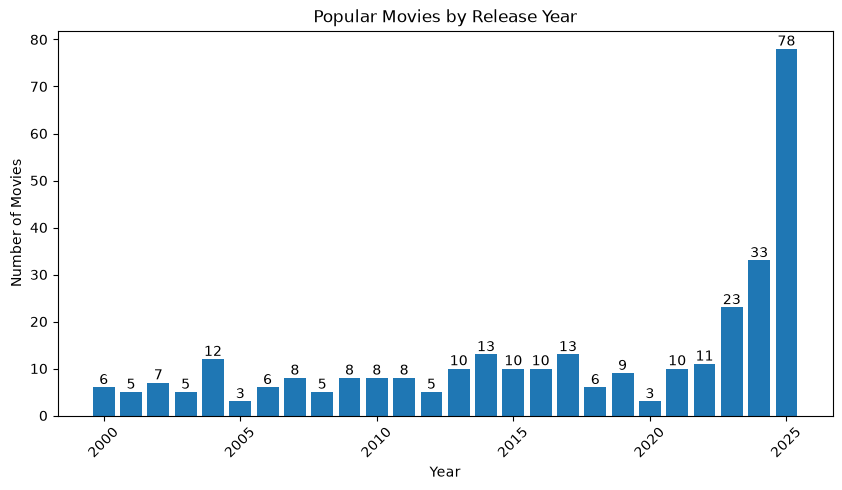

In [26]:
plt.figure(figsize=(10, 5))
bars = plt.bar(movies_per_year["year"], movies_per_year["Number of Movies"])
plt.title("Popular Movies by Release Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, str(int(height)), ha='center', va='bottom')

plt.show()

In [27]:
#analysis 2000s

df_2000_2009 = movies_df[(movies_df["year"] >= 2000) & (movies_df["year"] <= 2009)]
movies_per_year = df_2000_2009.groupby("year").size().reset_index(name="Number of Movies").astype(int)
movies_per_year = movies_per_year.sort_values(by="year")
total_movies=movies_per_year["Number of Movies"].sum()
print(total_movies)
movies_per_year.describe()




65


,year,Number of Movies
count,10.00000,10.000000
mean,2004.50000,6.500000
std,3.02765,2.460804
min,2000.00000,3.000000
25%,2002.25000,5.000000
50%,2004.50000,6.000000
75%,2006.75000,7.750000
max,2009.00000,12.000000


In [28]:

#anaysis 2010s
df_2010_2019 = movies_df[(movies_df["year"] >= 2010) & (movies_df["year"] <= 2019)]
movies_per_year = df_2010_2019.groupby("year").size().reset_index(name="Number of Movies").astype(int)
movies_per_year = movies_per_year.sort_values(by="year")
total_movies=movies_per_year["Number of Movies"].sum()
print(total_movies)
movies_per_year.describe()

92


,year,Number of Movies
count,10.00000,10.000000
mean,2014.50000,9.200000
std,3.02765,2.616189
min,2010.00000,5.000000
25%,2012.25000,8.000000
50%,2014.50000,9.500000
75%,2016.75000,10.000000
max,2019.00000,13.000000


# REVENUE FOR FILMS:

Question 2: Which movie genres generate the highest total revenue **among popular movies**?


In [30]:
genre_revenue = {}
for index, row in movies_df.iterrows():
    revenue = row["revenue"]
    genres = str(row["genres"]).split(", ")
    for genre in genres:
        if genre and genre != "nan":
            if genre not in genre_revenue:
                genre_revenue[genre] = 0

            genre_revenue[genre] += revenue  #genre_revenue returns a dictionary where the key is genre and value is total revenue


genre_revenue_df = pd.DataFrame(list(genre_revenue.items()), columns=["Genre", "Total Revenue (In Billions)"])
genre_revenue_df["Total Revenue (In Billions)"] = (genre_revenue_df["Total Revenue (In Billions)"] / 1_000_000_000).round(2) #converting total revenue to billions


genre_revenue_df = genre_revenue_df.sort_values("Total Revenue (In Billions)", ascending=False)
genre_revenue_df


,Genre,Total Revenue (In Billions)
2,Adventure,85.94
5,Action,73.93
9,Science Fiction,50.59
3,Fantasy,39.99
1,Comedy,33.63
0,Family,28.63
4,Animation,28.62
7,Drama,28.00
6,Thriller,17.91
10,Romance,13.79


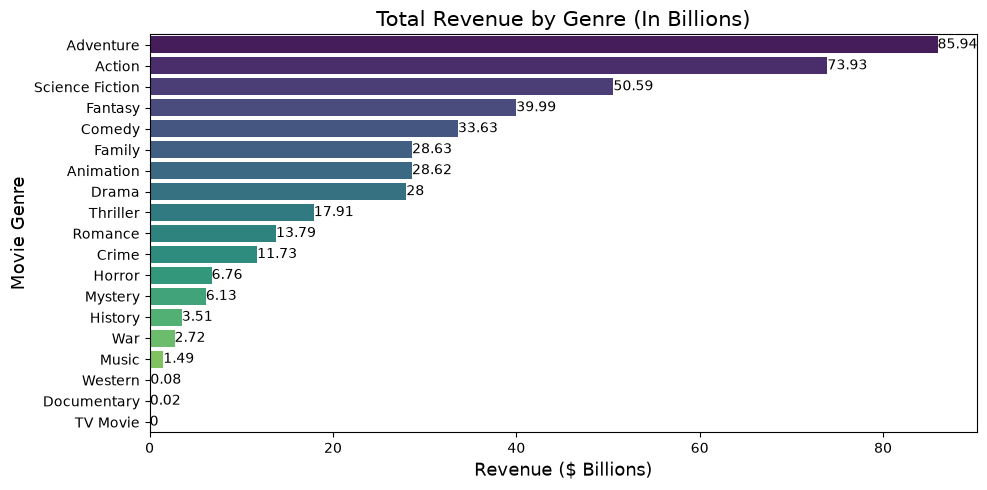

In [31]:
# creating bar plot
plt.figure(figsize=[10,5])
plot= sns.barplot(
    data=genre_revenue_df,
    x='Total Revenue (In Billions)',
    y='Genre',
    hue='Genre',
    palette='viridis',
)

#counter for bar counts
for container in plot.containers:
    plot.bar_label(container)

#adding title
plt.title('Total Revenue by Genre (In Billions)' , fontsize=15)
plt.xlabel('Revenue ($ Billions)',fontsize=13)
plt.ylabel('Movie Genre', fontsize=13)

plt.tight_layout()
plt.show()


In [32]:
#analysis for findings
genre_revenue_series = pd.Series(genre_revenue).sort_values(ascending=False)

total_revenue = genre_revenue_series.sum()
top3_revenues = genre_revenue_series.head(3).sum()
top3_percent = (top3_revenues / total_revenue) * 100

print(round(total_revenue / 1_000_000_000, 2))
print(round(top3_revenues / 1_000_000_000, 2))
print(round(top3_percent, 2))


433.46
210.45
48.55


# RATING FOR FILMS:

Question 3: Do longer popular movies receive better ratings?


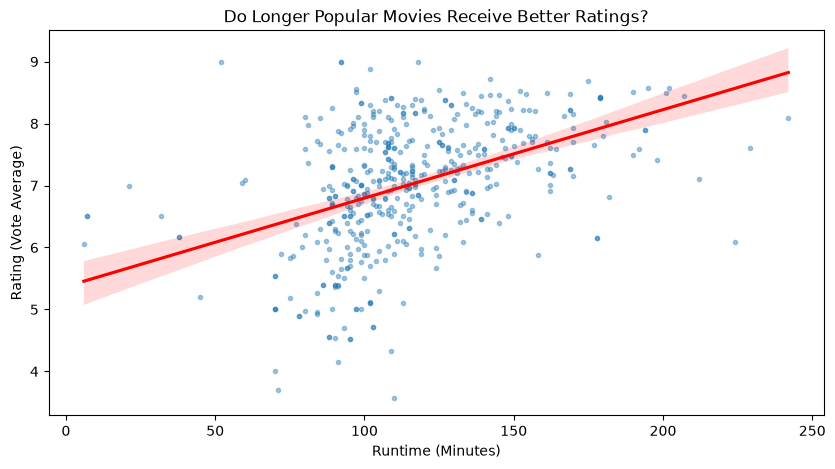

In [34]:
#filter data so that runtime and rating is above 0 and not na
df_runtime_rating = movies_df[
    (movies_df["runtime"].notna()) &
    (movies_df["runtime"] > 0) &
    (movies_df["rating"] > 0) &
    (movies_df["rating"].notna())]

#make scatter plot (relationship shown between 2 variables)
plt.figure(figsize=(10, 5))

sns.regplot(x="runtime", y="rating", data=df_runtime_rating,
            scatter_kws={'alpha':0.4}, #transparency of the marker
            marker='.', line_kws={'color': 'red'}) #line_kws is about the trend line

plt.title("Do Longer Popular Movies Receive Better Ratings?")
plt.xlabel("Runtime (Minutes)")
plt.ylabel("Rating (Vote Average)")
plt.show()

# GENRE ANALYSIS:

Question 4: What is the average movie runtime by genre?

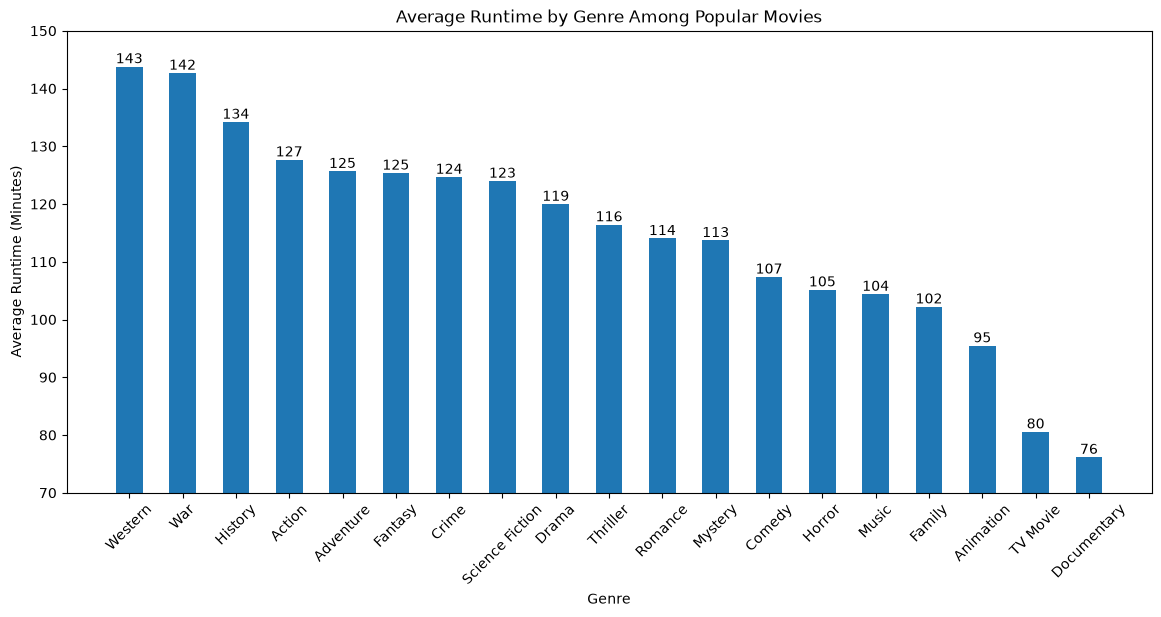

In [35]:
genre_runtime = {}
for index, row in movies_df.iterrows():
    runtime = row["runtime"]
    genres = str(row["genres"]).split(", ")

    if pd.notna(runtime) and runtime > 0:
        for genre in genres:
            if genre and genre != "nan":
                if genre not in genre_runtime:
                    genre_runtime[genre] = []

                genre_runtime[genre].append(runtime)

average_runtime = {}
for genre, runtimes in genre_runtime.items():
    average_runtime[genre] = sum(runtimes) / len(runtimes)


runtime_df = pd.DataFrame(list(average_runtime.items()), columns=["Genre", "Average Runtime"])
runtime_df = runtime_df.sort_values("Average Runtime", ascending=False)
runtime_df

plt.figure(figsize=(14, 6))
bars = plt.bar(runtime_df["Genre"], runtime_df["Average Runtime"], width = 0.5)
plt.title("Average Runtime by Genre Among Popular Movies")
plt.xlabel("Genre")
plt.ylabel("Average Runtime (Minutes)")
plt.ylim(70, 150) # Set y-axis
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, str(int(height)), ha='center', va='bottom')

plt.show()

In [36]:
#analysis
runtime_describe = movies_df[(movies_df["runtime"] > 0) & (movies_df["runtime"].notna())]["runtime"].describe()
print(runtime_describe)

count    490.000000
mean     115.842857
std       31.247704
min        6.000000
25%       96.000000
50%      110.000000
75%      132.750000
max      242.000000
Name: runtime, dtype: float64


Question 5: What is the average movie rating by genre?



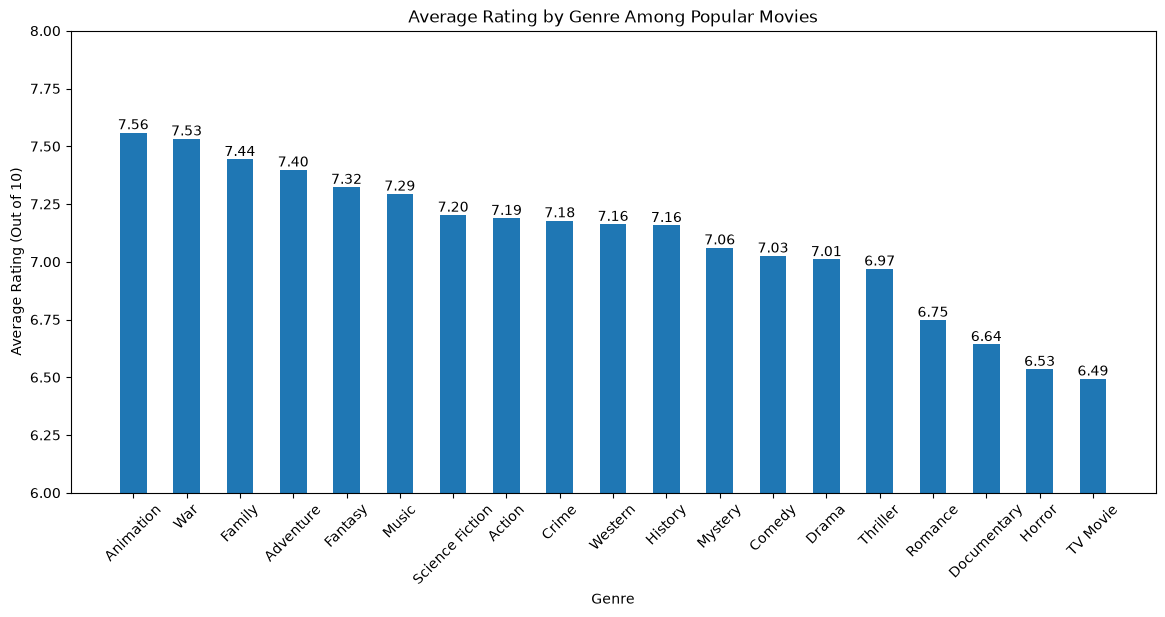

In [37]:
genre_rating = {}
for index, row in movies_df.iterrows():
    rating = row["rating"]
    genres = str(row["genres"]).split(", ")

    if pd.notna(rating) and rating > 0:
        for genre in genres:
            if genre and genre != "nan":
                if genre not in genre_rating:
                    genre_rating[genre] = []

                genre_rating[genre].append(rating)

average_rating = {}
for genre, ratings in genre_rating.items():
    average_rating[genre] = sum(ratings) / len(ratings)

rating_df = pd.DataFrame(list(average_rating.items()), columns=["Genre", "Average Rating"])
rating_df = rating_df.sort_values("Average Rating", ascending=False)
rating_df

plt.figure(figsize=(14, 6))
bars = plt.bar(rating_df["Genre"], rating_df["Average Rating"], width = 0.5)
plt.title("Average Rating by Genre Among Popular Movies")
plt.xlabel("Genre")
plt.ylabel("Average Rating (Out of 10)")
plt.ylim(6, 8) # Set y-axis
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}', ha='center', va='bottom') #set to two decimal points

plt.show()